# Part B — Stock Market Risk Analysis
## Weekly Stock Price & Returns Analysis for Five Indian Equities

**Objective:** Analyse weekly stock price data for five major Indian equities to quantify their risk-return profiles and provide portfolio allocation recommendations.

**Dataset:** `Market_Risk_Data_coded.csv`  
- 418 weekly observations | March 2016 – March 2024  
- Stocks: ITC Limited, Bharti Airtel, Tata Motors, DLF Limited, Yes Bank

---
### Table of Contents
1. Import Libraries  
2. Load & Inspect Data  
3. Stock Price Graph Analysis  
4. Stock Returns Calculation  
5. Mean & Standard Deviation of Returns  
6. Mean vs Standard Deviation Plot (Risk-Return Profile)  
7. Actionable Insights & Recommendations

---
## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('Libraries imported successfully.')

Libraries imported successfully.


---
## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('Market_Risk_Data_coded.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min().strftime("%d %b %Y")} to {df["Date"].max().strftime("%d %b %Y")}')
print(f'Number of weeks: {len(df)}')
df.head(10)

Shape: (418, 6)
Date range: 28 Mar 2016 to 25 Mar 2024
Number of weeks: 418


,Date,ITC Limited,Bharti Airtel,Tata Motors,DLF Limited,Yes Bank
0,2016-03-28,217,316,386,114,173
1,2016-04-04,218,302,386,121,171
2,2016-04-11,215,308,374,120,171
3,2016-04-18,223,320,408,122,172
4,2016-04-25,214,319,418,122,175
5,2016-05-02,216,327,408,129,190
6,2016-05-09,213,325,400,127,183
7,2016-05-16,212,320,394,122,191
8,2016-05-23,233,312,389,124,197
9,2016-05-30,236,318,405,129,205


In [3]:
print('Data Types:')
print(df.dtypes)

Data Types:
Date             datetime64[us]
ITC Limited               int64
Bharti Airtel             int64
Tata Motors               int64
DLF Limited               int64
Yes Bank                  int64
dtype: object


In [4]:
stocks = ['ITC Limited', 'Bharti Airtel', 'Tata Motors', 'DLF Limited', 'Yes Bank']
print('Statistical Summary — Stock Prices (INR):')
df[stocks].describe().round(2)

Statistical Summary — Stock Prices (INR):


,ITC Limited,Bharti Airtel,Tata Motors,DLF Limited,Yes Bank
count,418.0000,418.0000,418.0000,418.0000,418.0000
mean,278.9600,528.2600,368.6200,276.8300,124.4400
std,75.1100,226.5100,182.0200,156.2800,130.0900
min,156.0000,261.0000,65.0000,110.0000,11.0000
25%,224.2500,334.0000,186.0000,166.2500,16.0000
50%,265.5000,478.0000,399.5000,213.0000,30.0000
75%,304.0000,706.7500,466.0000,360.5000,249.7500
max,493.0000,1236.0000,1035.0000,928.0000,397.0000


**Key Observations:**
- No missing values — all 418 weeks have complete price data for all 5 stocks.
- Price ranges vary enormously across stocks: Yes Bank spans INR 11–397; Bharti Airtel INR 261–1,236.
- Yes Bank has the highest standard deviation relative to its mean (coefficient of variation ≈ 1.05), indicating extreme volatility.
- ITC Limited has the lowest coefficient of variation (≈ 0.27), marking it the most stable.

---
## 3. Stock Price Graph Analysis
### 3.1 Individual Stock Price Series

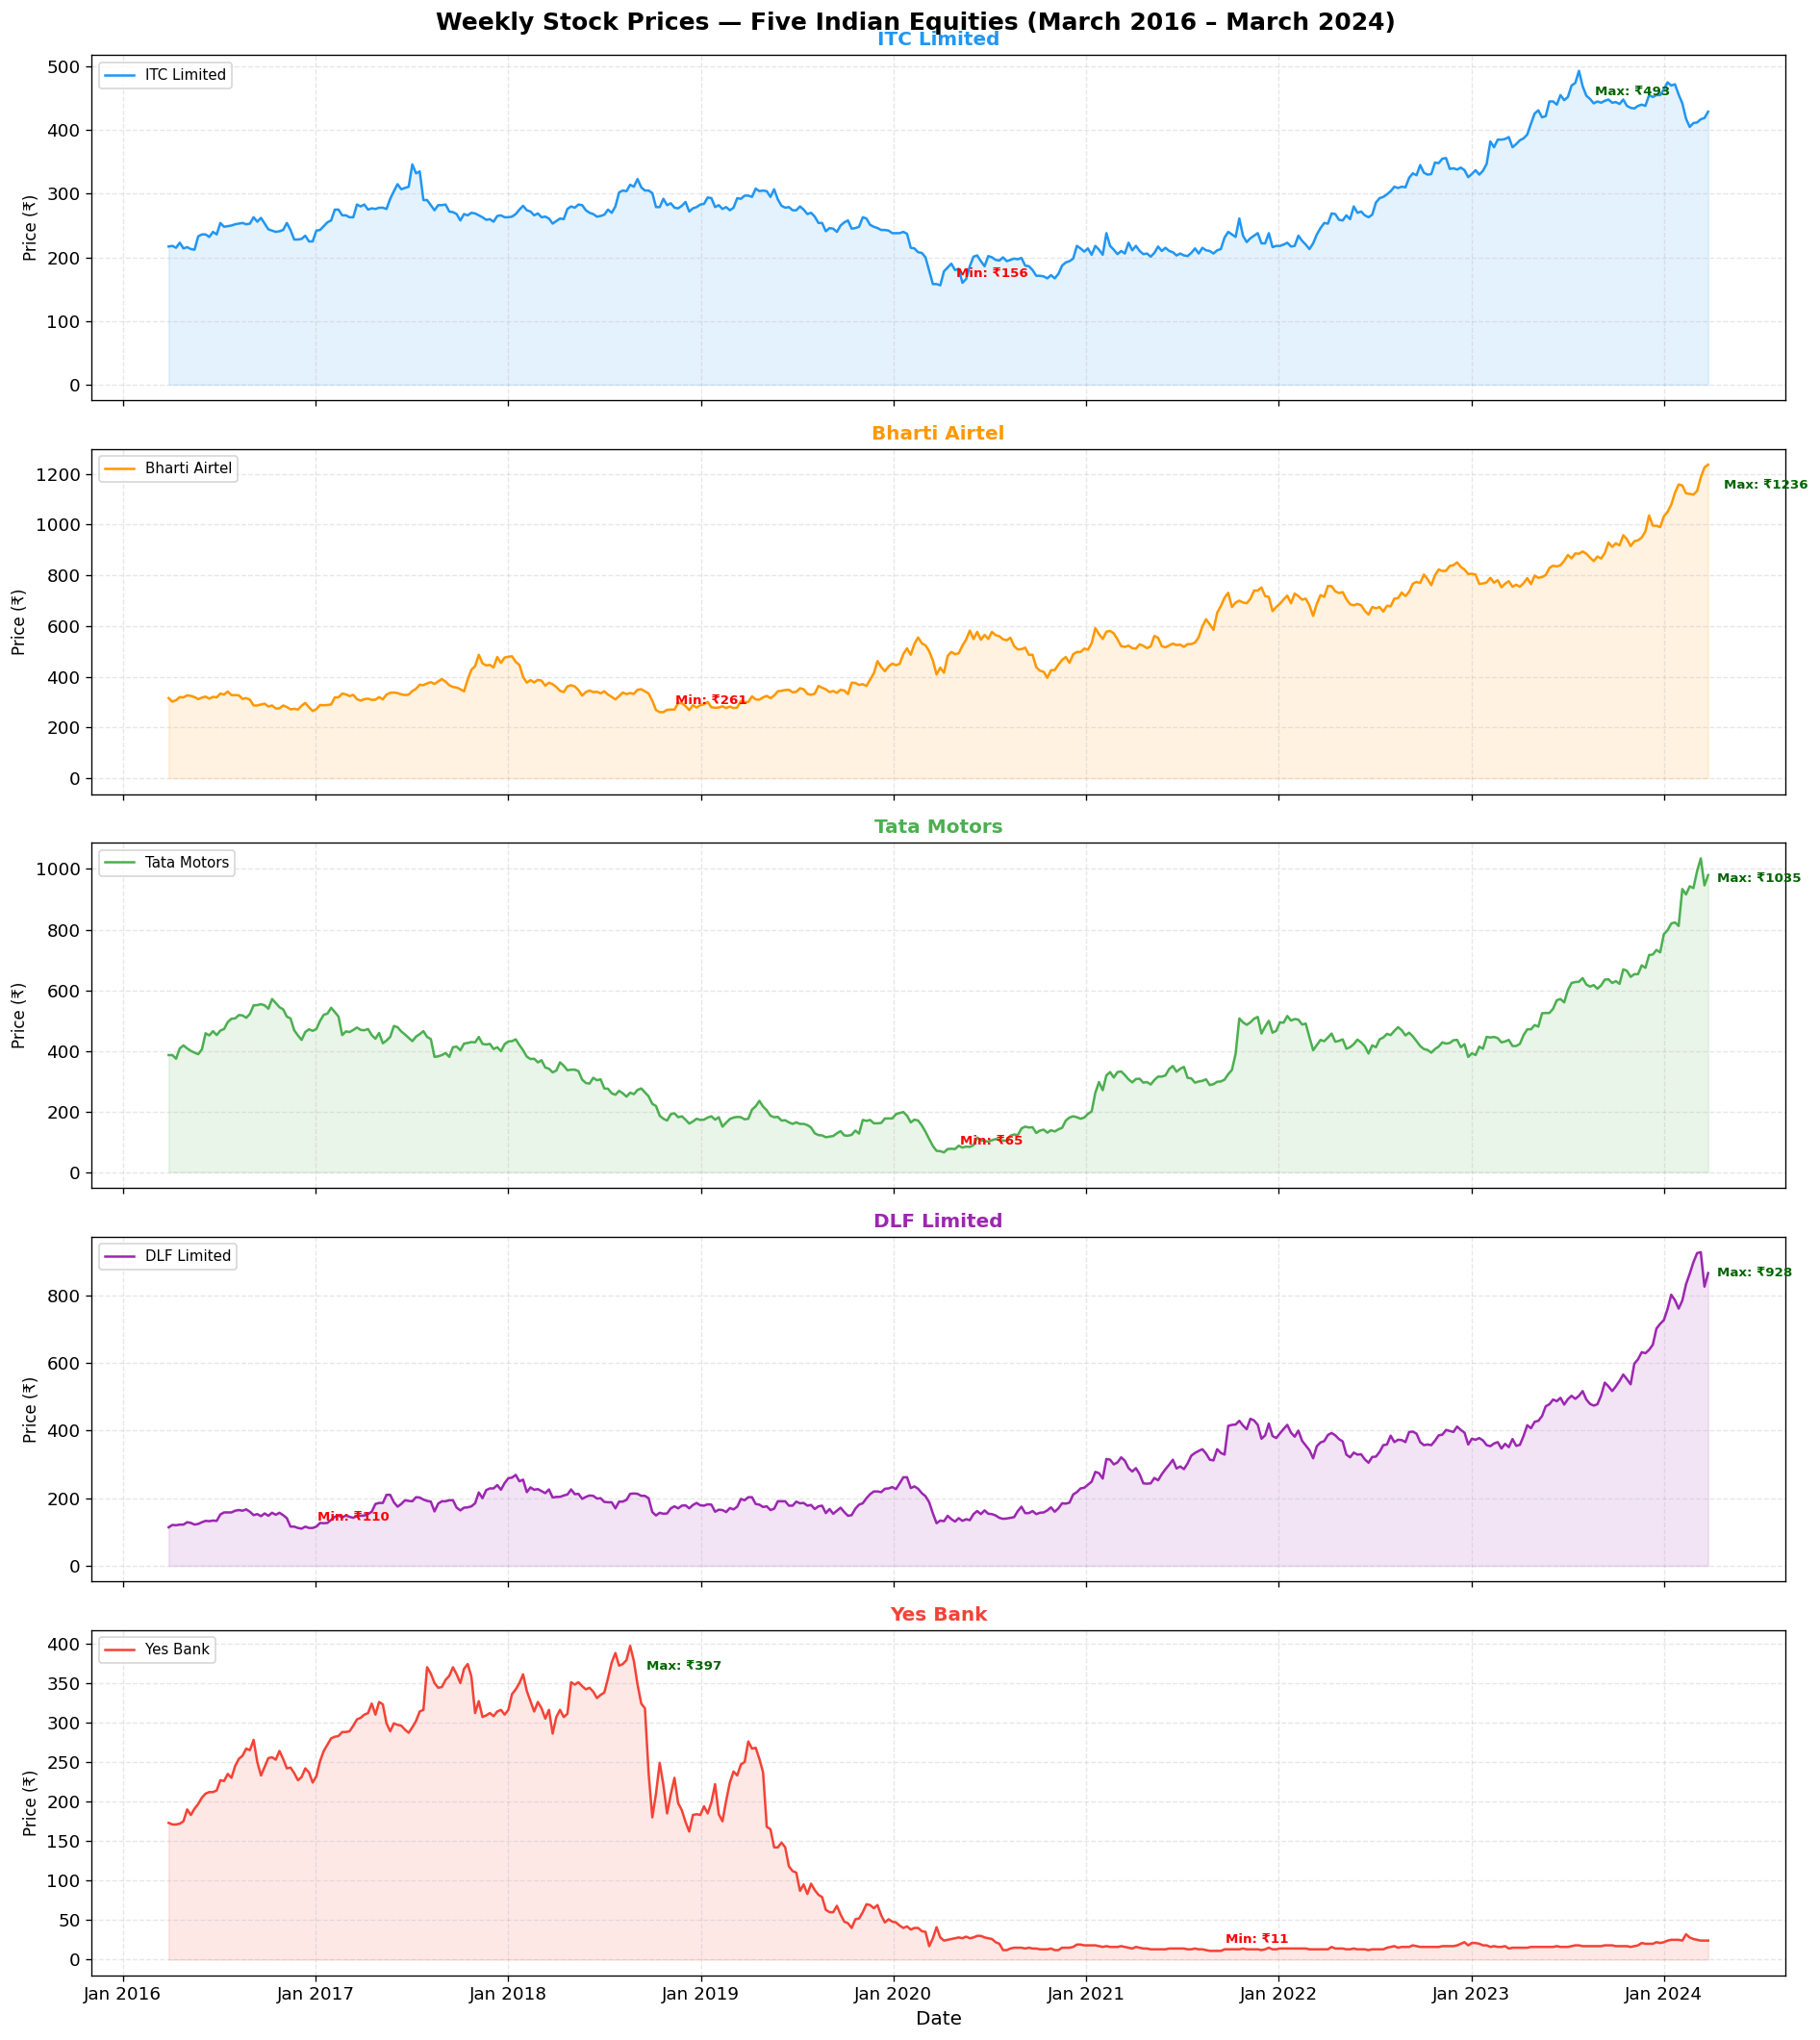

Observations:
- ITC Limited    : Steady, gradual appreciation with strong uptrend from 2022 onwards.
- Bharti Airtel  : Prolonged trough (2018-2020, Jio disruption), then strong sustained recovery.
- Tata Motors    : Highest intra-period amplitude; COVID crash (min ~₹65) followed by strong recovery.
- DLF Limited    : Real estate cyclicality — long sideways period, then late-cycle surge (2023-24).
- Yes Bank       : Catastrophic collapse from ₹397 to ₹11 (governance crisis + RBI rescue, 2020);
                   shareholder value permanently destroyed for the period under review.


In [5]:
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']

fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

for ax, stock, color in zip(axes, stocks, colors):
    ax.plot(df['Date'], df[stock], color=color, linewidth=1.5, label=stock)
    ax.fill_between(df['Date'], df[stock], alpha=0.12, color=color)
    ax.set_ylabel('Price (₹)', fontsize=10)
    ax.set_title(stock, fontsize=12, fontweight='bold', color=color)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=9, loc='upper left')

    # Annotate min and max
    idx_max = df[stock].idxmax()
    idx_min = df[stock].idxmin()
    ax.annotate(f'Max: ₹{df[stock].max():.0f}', xy=(df['Date'][idx_max], df[stock].max()),
                xytext=(10, -15), textcoords='offset points', fontsize=8,
                color='darkgreen', fontweight='bold')
    ax.annotate(f'Min: ₹{df[stock].min():.0f}', xy=(df['Date'][idx_min], df[stock].min()),
                xytext=(10, 5), textcoords='offset points', fontsize=8,
                color='red', fontweight='bold')

axes[-1].set_xlabel('Date', fontsize=12)
plt.suptitle('Weekly Stock Prices — Five Indian Equities (March 2016 – March 2024)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("""Observations:
- ITC Limited    : Steady, gradual appreciation with strong uptrend from 2022 onwards.
- Bharti Airtel  : Prolonged trough (2018-2020, Jio disruption), then strong sustained recovery.
- Tata Motors    : Highest intra-period amplitude; COVID crash (min ~₹65) followed by strong recovery.
- DLF Limited    : Real estate cyclicality — long sideways period, then late-cycle surge (2023-24).
- Yes Bank       : Catastrophic collapse from ₹397 to ₹11 (governance crisis + RBI rescue, 2020);
                   shareholder value permanently destroyed for the period under review.""")

### 3.2 All Stocks — Normalised Price Index (Base = 100)

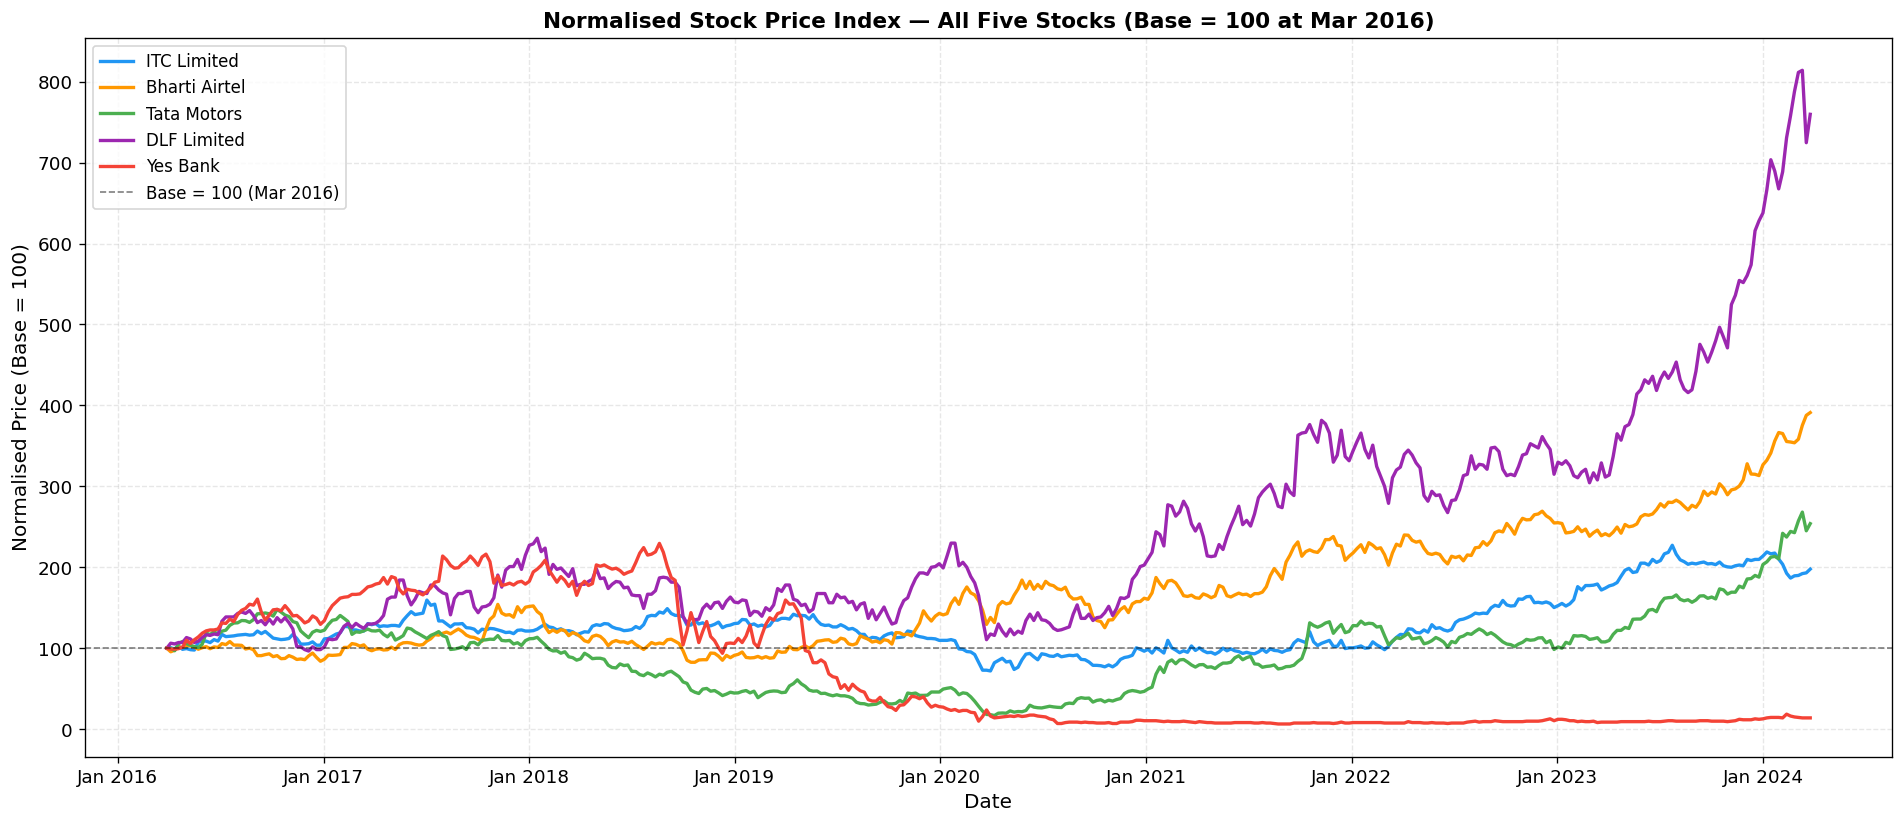

Total Return over ~8 years (normalised):
  ITC Limited         : +97.7%
  Bharti Airtel       : +291.1%
  Tata Motors         : +153.9%
  DLF Limited         : +659.6%
  Yes Bank            : -86.1%


In [6]:
# Normalise prices to 100 at the start for comparison
base = df[stocks].iloc[0]
normalised = (df[stocks] / base) * 100

fig, ax = plt.subplots(figsize=(16, 7))
for stock, color in zip(stocks, colors):
    ax.plot(df['Date'], normalised[stock], color=color, linewidth=2, label=stock)

ax.axhline(100, color='black', linewidth=1, linestyle='--', alpha=0.5, label='Base = 100 (Mar 2016)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalised Price (Base = 100)', fontsize=12)
ax.set_title('Normalised Stock Price Index — All Five Stocks (Base = 100 at Mar 2016)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

final_returns = (normalised.iloc[-1] - 100).round(1)
print('Total Return over ~8 years (normalised):')
for stock in stocks:
    print(f'  {stock:20s}: {final_returns[stock]:+.1f}%')

---
## 4. Stock Returns Calculation
**Formula:** Weekly Return (%) = (Price_t - Price_{t-1}) / Price_{t-1} × 100

This measures the percentage price change from one week to the next.

In [7]:
returns = df[stocks].pct_change() * 100   # Weekly returns in %
returns = returns.dropna().reset_index(drop=True)
returns_dates = df['Date'].iloc[1:].reset_index(drop=True)

print(f'Returns calculated for {len(returns)} weeks.')
print('\nFirst 5 rows of weekly returns (%):')
returns.head()

Returns calculated for 417 weeks.

First 5 rows of weekly returns (%):


,ITC Limited,Bharti Airtel,Tata Motors,DLF Limited,Yes Bank
0,0.4608,-4.4304,0.0000,6.1404,-1.1561
1,-1.3761,1.9868,-3.1088,-0.8264,0.0000
2,3.7209,3.8961,9.0909,1.6667,0.5848
3,-4.0359,-0.3125,2.4510,0.0000,1.7442
4,0.9346,2.5078,-2.3923,5.7377,8.5714


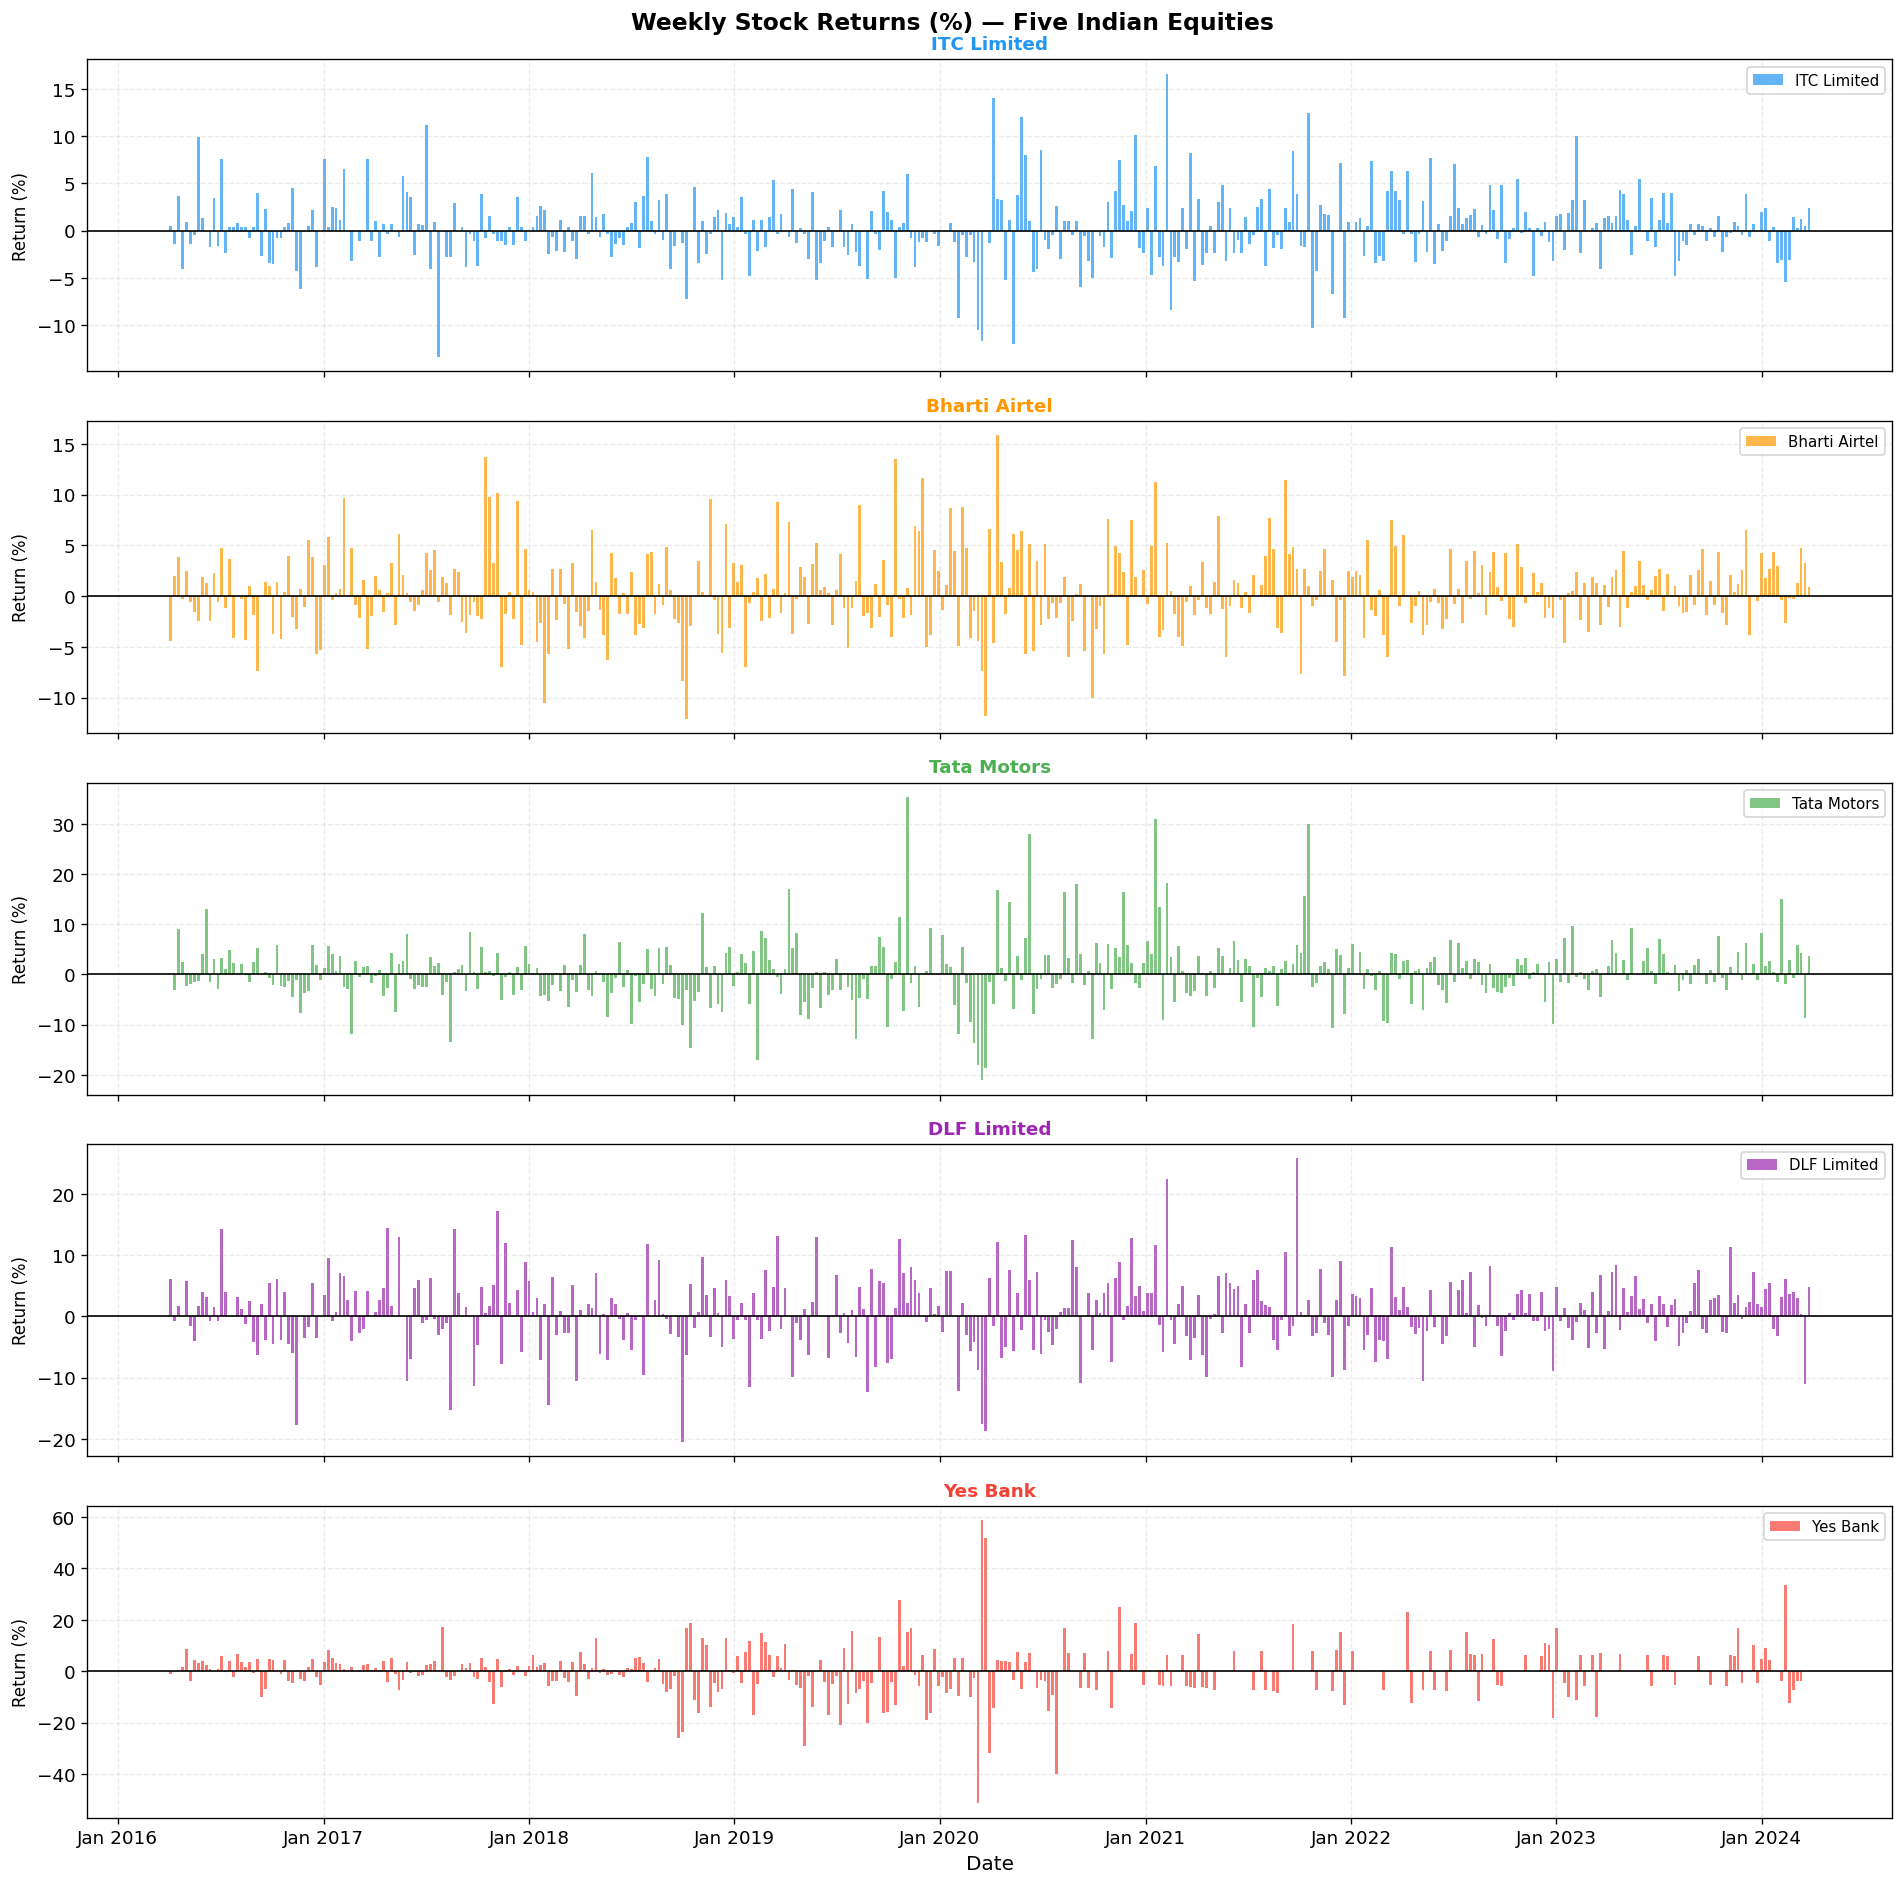

Observation: Yes Bank exhibits extreme return spikes (both positive and negative) around its 2020 crisis.
Tata Motors and DLF also show elevated volatility, especially during the COVID crash (early 2020).


In [8]:
# Returns over time
fig, axes = plt.subplots(5, 1, figsize=(16, 16), sharex=True)

for ax, stock, color in zip(axes, stocks, colors):
    ax.bar(returns_dates, returns[stock], color=color, alpha=0.7, width=5, label=stock)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel('Return (%)', fontsize=10)
    ax.set_title(stock, fontsize=11, fontweight='bold', color=color)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('Date', fontsize=12)
plt.suptitle('Weekly Stock Returns (%) — Five Indian Equities', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observation: Yes Bank exhibits extreme return spikes (both positive and negative) around its 2020 crisis.\nTata Motors and DLF also show elevated volatility, especially during the COVID crash (early 2020).')

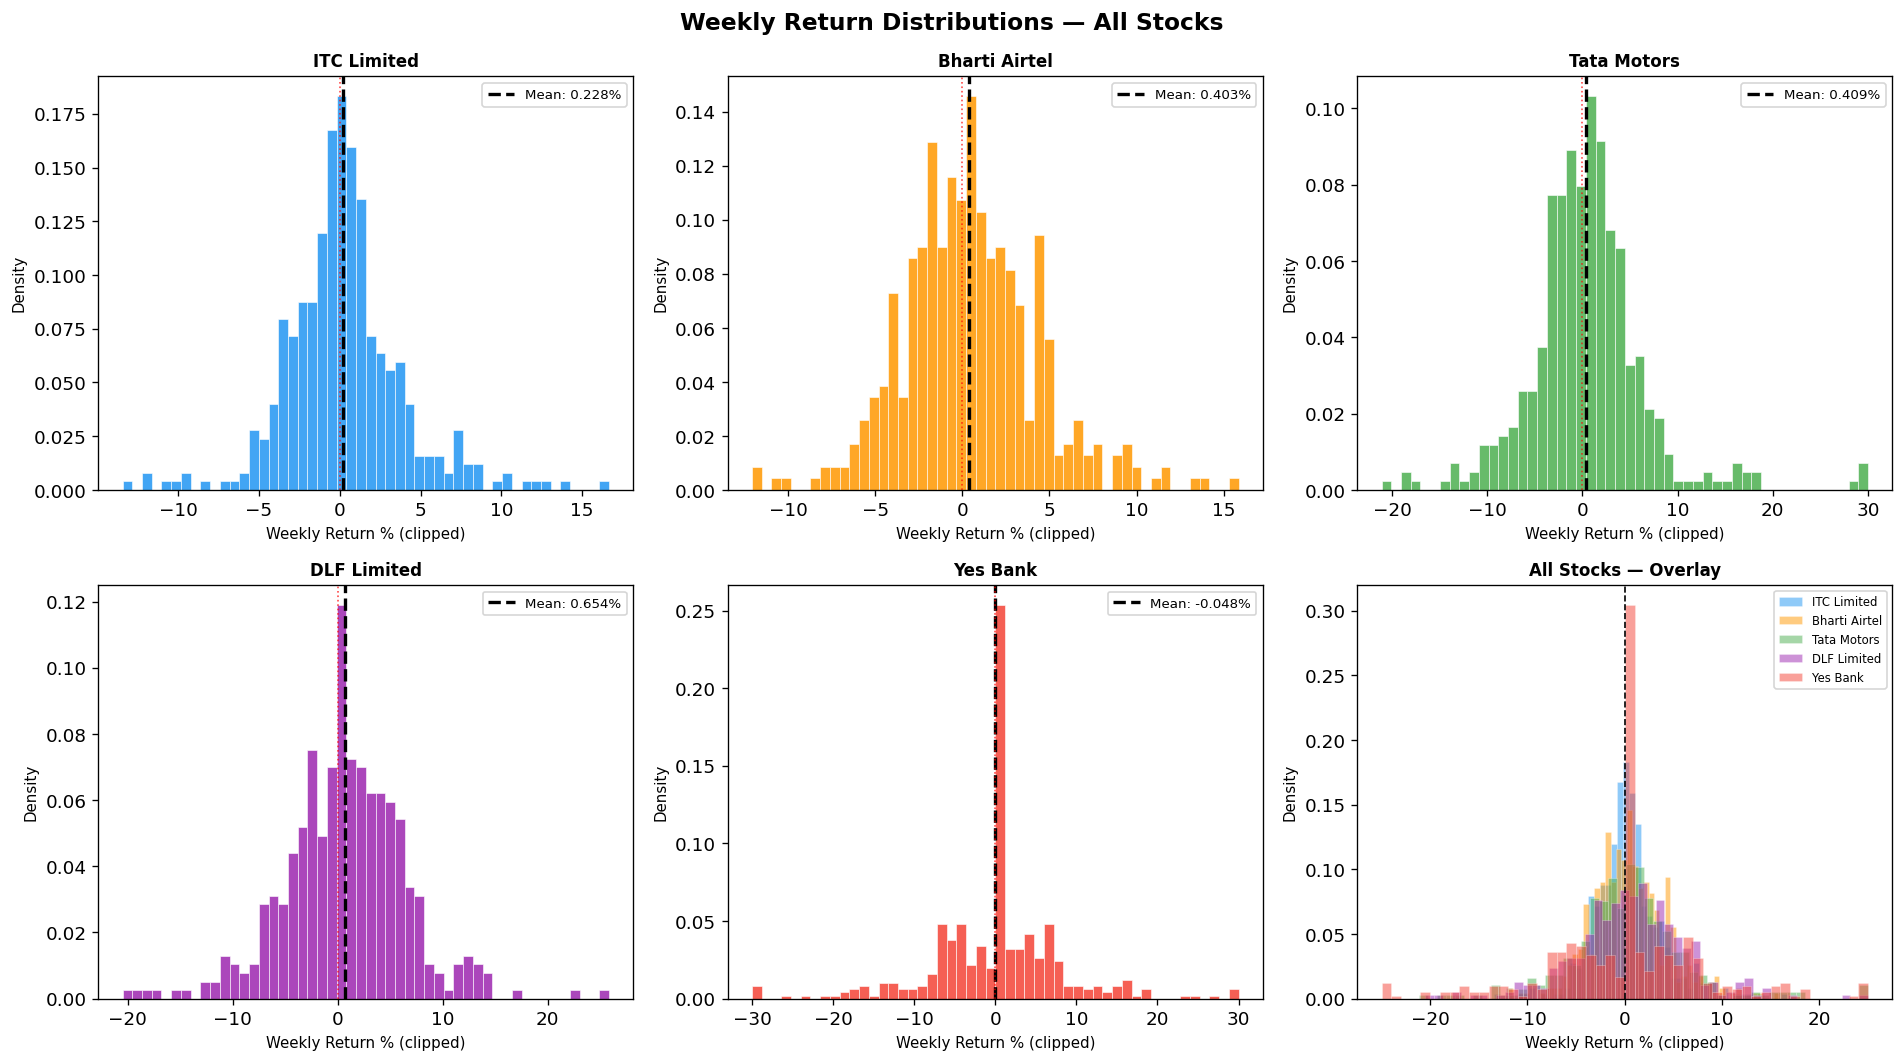

Observation: All distributions are approximately symmetric around zero (leptokurtic).
Yes Bank has the fattest tails — highest kurtosis and extreme tail events.


In [ ]:
# Returns distribution — histogram
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, stock, color in zip(axes[:5], stocks, colors):
    data = returns[stock].clip(-30, 30)
    ax.hist(data, bins=50, color=color, edgecolor='white', linewidth=0.4, alpha=0.85, density=True)
    ax.axvline(returns[stock].mean(), color='black', linewidth=2, linestyle='--',
               label=f'Mean: {returns[stock].mean():.3f}%')
    ax.axvline(0, color='red', linewidth=1, linestyle=':', alpha=0.7)
    ax.set_xlabel('Weekly Return % (clipped)', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_title(stock, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

# Overlay comparison in 6th panel
for stock, color in     zip(stocks, colors):
    axes[5].hist(returns[stock].clip(-25, 25), bins=50, alpha=0.5,
                 color=color, edgecolor='white', linewidth=0.3, density=True, label=stock)
axes[5].axvline(0, color='black', linewidth=1, linestyle='--')
axes[5].set_xlabel('Weekly Return % (clipped)', fontsize=9)
axes[5].set_ylabel('Density', fontsize=9)
axes[5].set_title('All Stocks — Overlay', fontsize=10, fontweight='bold')
axes[5].legend(fontsize=7)

plt.suptitle('Weekly Return Distributions — All Stocks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observation: All distributions are approximately symmetric around zero (leptokurtic).\nYes Bank has the fattest tails — highest kurtosis and extreme tail events.')

---
## 5. Mean & Standard Deviation of Weekly Returns

In [10]:
stats = pd.DataFrame({
    'Mean Return (%)':  returns[stocks].mean().round(4),
    'Std Dev (%)':      returns[stocks].std().round(4),
    'Min Return (%)':   returns[stocks].min().round(4),
    'Max Return (%)':   returns[stocks].max().round(4),
    'Skewness':         returns[stocks].skew().round(4),
    'Kurtosis':         returns[stocks].kurt().round(4),
    'Sharpe-like Ratio (Mean/Std)': (returns[stocks].mean() / returns[stocks].std()).round(4)
})

print('Risk-Return Statistics — All Stocks (Weekly Returns):')
stats

Risk-Return Statistics — All Stocks (Weekly Returns):


,Mean Return (%),Std Dev (%),Min Return (%),Max Return (%),Skewness,Kurtosis,Sharpe-like Ratio (Mean/Std)
ITC Limited,0.2281,3.6127,-13.4328,16.6667,0.3979,2.8874,0.0631
Bharti Airtel,0.4029,3.9073,-12.0915,15.8654,0.3871,1.2660,0.1031
Tata Motors,0.4088,6.1976,-21.1009,35.4331,1.0772,6.1588,0.0660
DLF Limited,0.6540,5.7796,-20.5000,25.8359,0.0189,1.8645,0.1132
Yes Bank,-0.0475,9.1095,-51.4286,58.8235,0.4332,10.0753,-0.0052


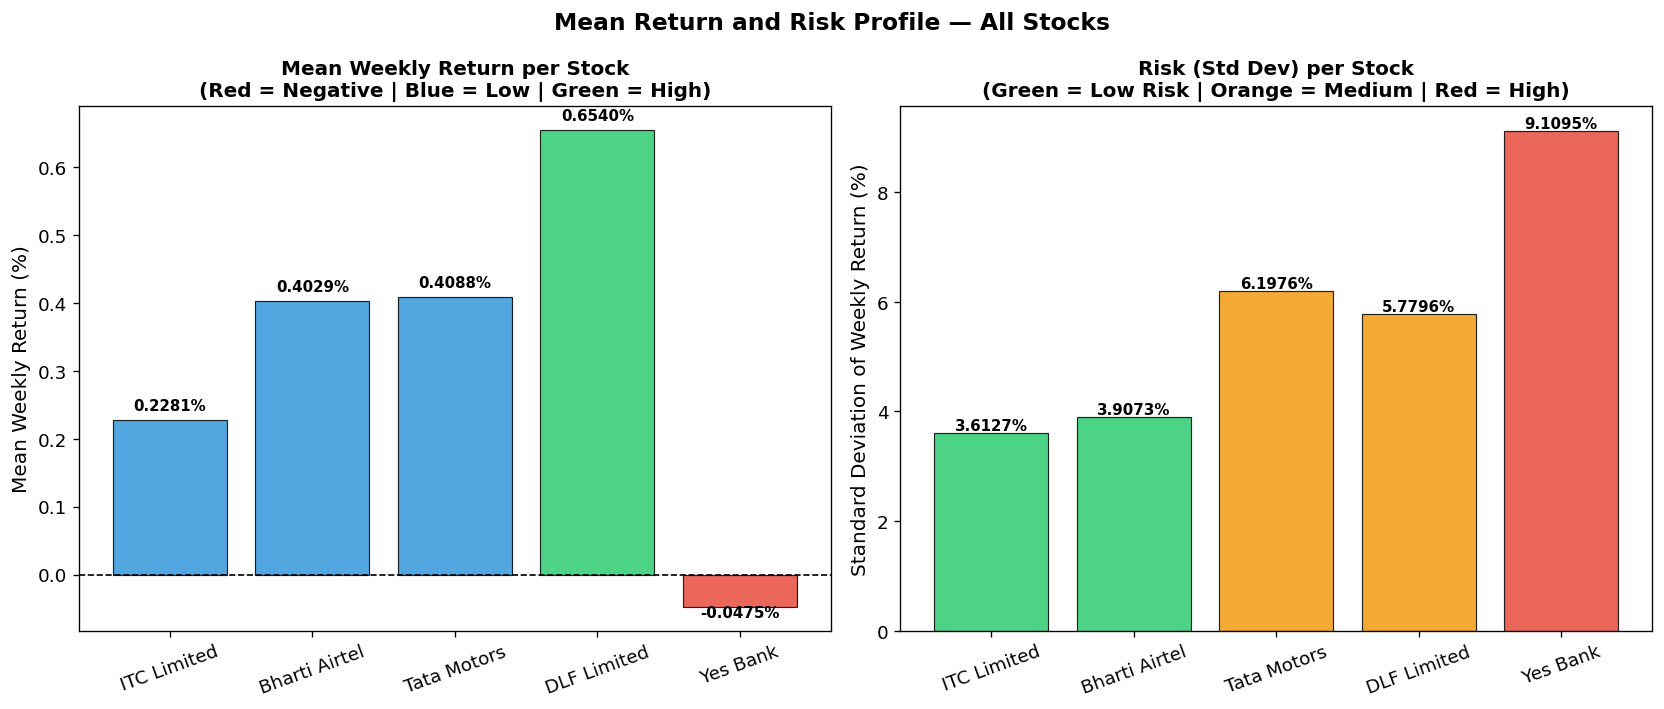

Key finding:
  Best mean return : DLF Limited   (+0.6540%/week)
  Lowest risk      : ITC Limited   (Std Dev = 3.6127%)
  Worst performer  : Yes Bank      (-0.0475%/week, Std Dev = 9.1095%)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mean return bar chart
mean_vals = stats['Mean Return (%)']
clrs = ['#e74c3c' if v < 0 else '#2ecc71' if v > 0.5 else '#3498db' for v in mean_vals]
bars = axes[0].bar(stocks, mean_vals, color=clrs, edgecolor='black', linewidth=0.7, alpha=0.85)
for bar, val in zip(bars, mean_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + (0.01 if val >= 0 else -0.02),
                 f'{val:.4f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_ylabel('Mean Weekly Return (%)', fontsize=12)
axes[0].set_title('Mean Weekly Return per Stock\n(Red = Negative | Blue = Low | Green = High)',
                  fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Standard deviation bar chart
std_vals = stats['Std Dev (%)']
clrs_std = ['#e74c3c' if v > 7 else '#f39c12' if v > 5 else '#2ecc71' for v in std_vals]
bars2 = axes[1].bar(stocks, std_vals, color=clrs_std, edgecolor='black', linewidth=0.7, alpha=0.85)
for bar, val in zip(bars2, std_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.4f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylabel('Standard Deviation of Weekly Return (%)', fontsize=12)
axes[1].set_title('Risk (Std Dev) per Stock\n(Green = Low Risk | Orange = Medium | Red = High)',
                  fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Mean Return and Risk Profile — All Stocks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key finding:')
print(f'  Best mean return : DLF Limited   ({stats.loc["DLF Limited", "Mean Return (%)"]:+.4f}%/week)')
print(f'  Lowest risk      : ITC Limited   (Std Dev = {stats.loc["ITC Limited", "Std Dev (%)"]:.4f}%)')
print(f'  Worst performer  : Yes Bank      ({stats.loc["Yes Bank", "Mean Return (%)"]:+.4f}%/week, Std Dev = {stats.loc["Yes Bank", "Std Dev (%)"]:.4f}%)')

---
## 6. Mean vs Standard Deviation Plot (Risk-Return Profile)

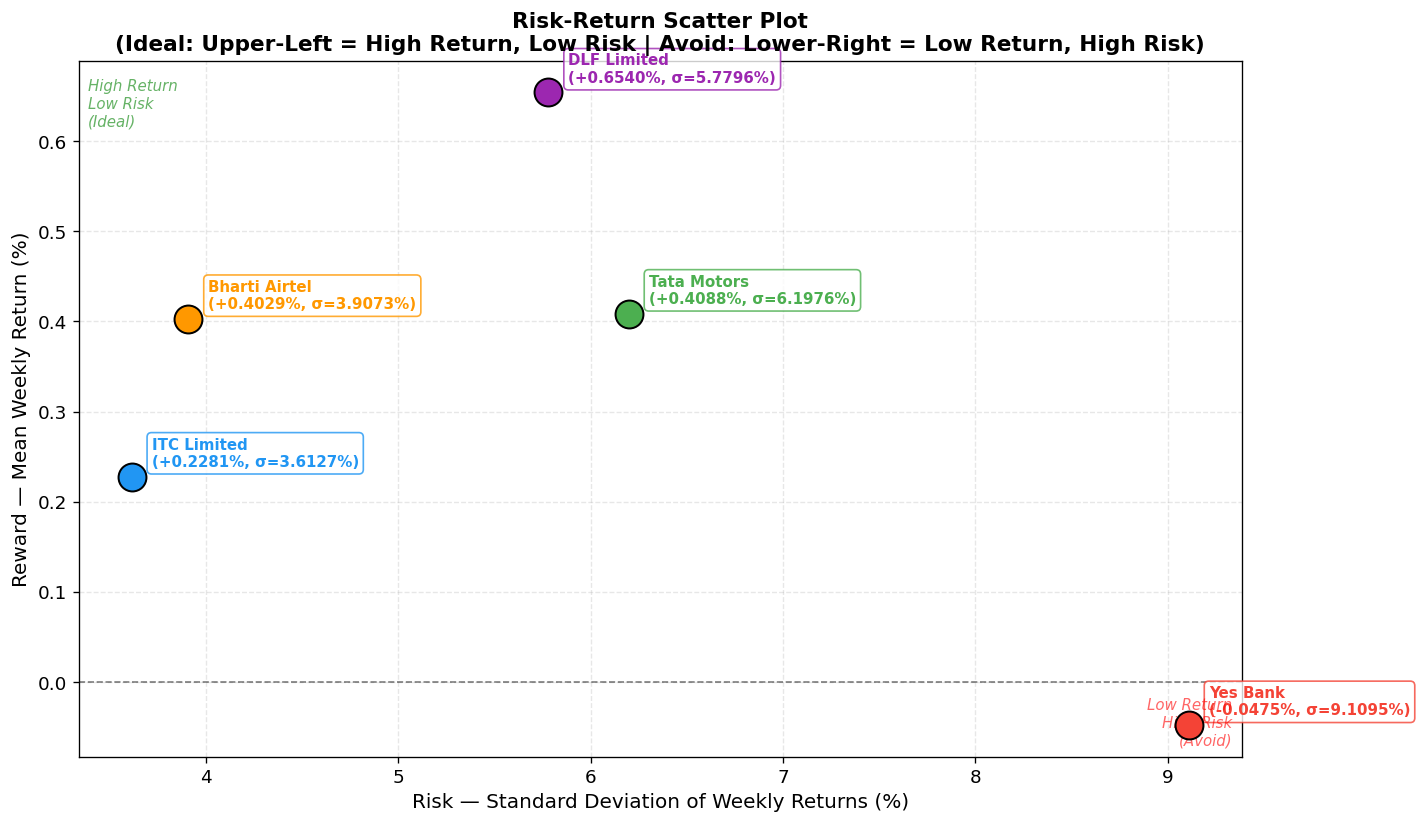

Risk-Return Quadrant Analysis:

BEST RISK-ADJUSTED:  Bharti Airtel — moderate return (0.40%), moderate risk (3.91%)
HIGHEST RETURN:      DLF Limited   — highest mean return (0.65%) but elevated risk (5.78%)
DEFENSIVE/STABLE:    ITC Limited   — lowest risk (3.61%) with positive return (0.23%)
CYCLICAL/HIGH-BETA:  Tata Motors   — similar return to Airtel (0.41%) but higher risk (6.20%)
AVOID:               Yes Bank      — NEGATIVE mean return (-0.05%) AND highest risk (9.11%)
                                     Bottom-right quadrant = worst possible combination


In [14]:
fig, ax = plt.subplots(figsize=(12, 7))

for stock, color in zip(stocks, colors):
    x_val = stats.loc[stock, 'Std Dev (%)']
    y_val = stats.loc[stock, 'Mean Return (%)']
    ax.scatter(x_val, y_val, color=color, s=280, zorder=5,
               edgecolors='black', linewidth=1.2)
    ax.annotate(
        f'{stock}\n({y_val:+.4f}%, σ={x_val:.4f}%)',
        (x_val, y_val),
        xytext=(12, 6), textcoords='offset points',
        fontsize=9, color=color, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.8)
    )

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Risk — Standard Deviation of Weekly Returns (%)', fontsize=12)
ax.set_ylabel('Reward — Mean Weekly Return (%)', fontsize=12)
ax.set_title('Risk-Return Scatter Plot\n(Ideal: Upper-Left = High Return, Low Risk | Avoid: Lower-Right = Low Return, High Risk)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Quadrant labels
xlim = ax.get_xlim(); ylim = ax.get_ylim()
ax.text(xlim[0]+0.05, ylim[1]-0.02, 'High Return\nLow Risk\n(Ideal)', fontsize=9, color='green',
        ha='left', va='top', style='italic', alpha=0.6)
ax.text(xlim[1]-0.05, ylim[0]+0.01, 'Low Return\nHigh Risk\n(Avoid)', fontsize=9, color='red',
        ha='right', va='bottom', style='italic', alpha=0.6)

plt.tight_layout()
plt.show()

print("""Risk-Return Quadrant Analysis:

BEST RISK-ADJUSTED:  Bharti Airtel — moderate return (0.40%), moderate risk (3.91%)
HIGHEST RETURN:      DLF Limited   — highest mean return (0.65%) but elevated risk (5.78%)
DEFENSIVE/STABLE:    ITC Limited   — lowest risk (3.61%) with positive return (0.23%)
CYCLICAL/HIGH-BETA:  Tata Motors   — similar return to Airtel (0.41%) but higher risk (6.20%)
AVOID:               Yes Bank      — NEGATIVE mean return (-0.05%) AND highest risk (9.11%)
                                     Bottom-right quadrant = worst possible combination""")

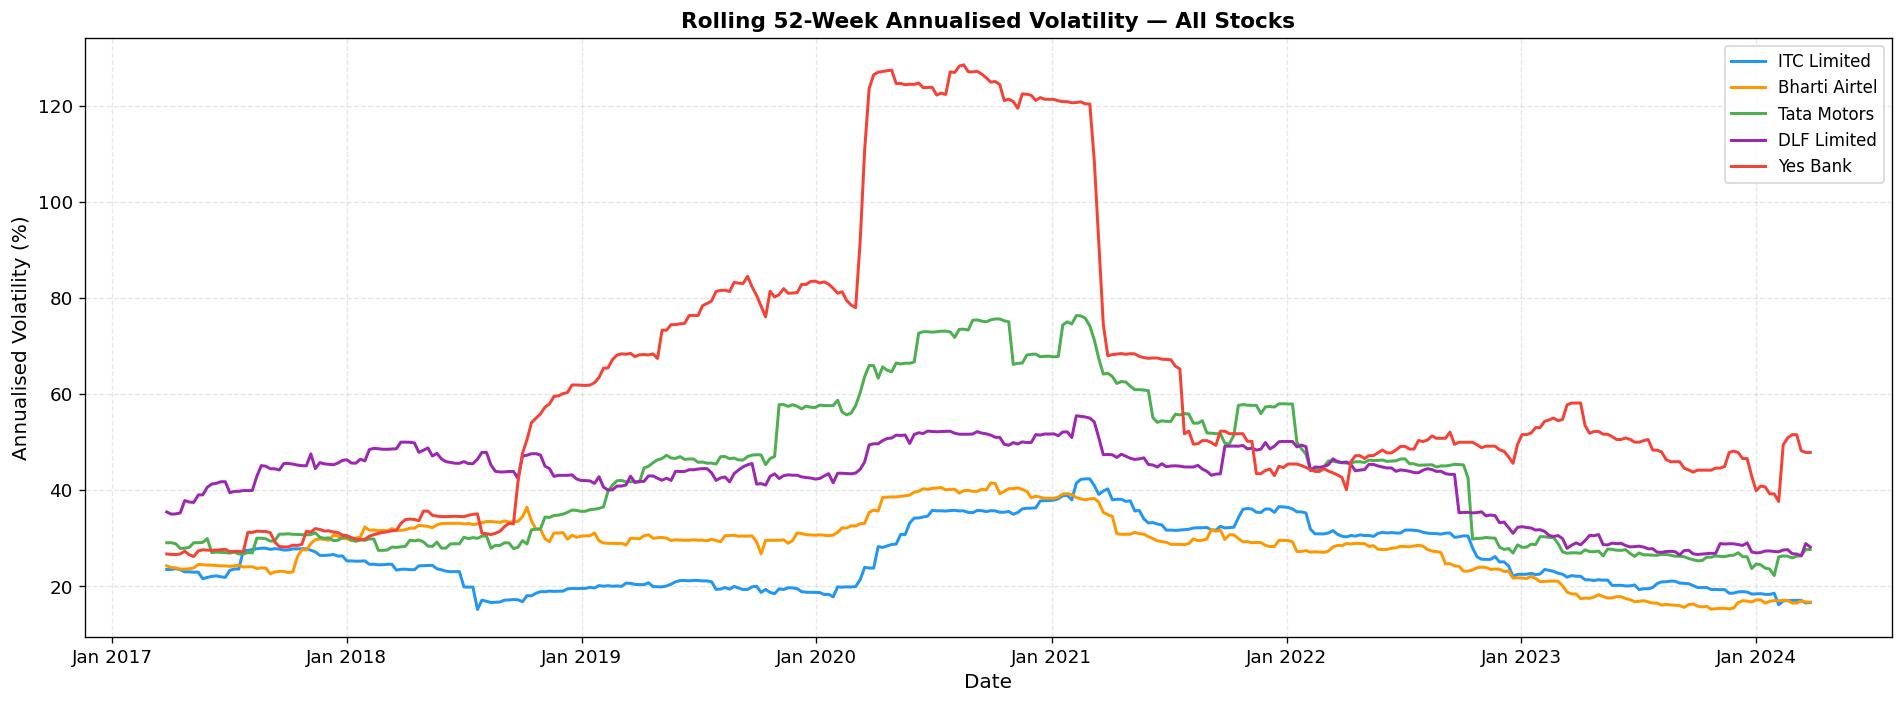

Observation: Yes Bank volatility spiked dramatically in 2020 (governance crisis).
All stocks showed elevated volatility during March 2020 (COVID market crash).
Post-2021, most stocks have returned to lower volatility regimes.


In [15]:
# Rolling 52-week (annual) volatility
rolling_vol = returns[stocks].rolling(window=52).std() * np.sqrt(52)  # Annualised

fig, ax = plt.subplots(figsize=(16, 6))
for stock, color in zip(stocks, colors):
    ax.plot(returns_dates[51:], rolling_vol[stock].dropna(),
            color=color, linewidth=1.8, label=stock)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Annualised Volatility (%)', fontsize=12)
ax.set_title('Rolling 52-Week Annualised Volatility — All Stocks', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
print('Observation: Yes Bank volatility spiked dramatically in 2020 (governance crisis).\nAll stocks showed elevated volatility during March 2020 (COVID market crash).\nPost-2021, most stocks have returned to lower volatility regimes.')

Correlation Matrix of Weekly Returns:
               ITC Limited  Bharti Airtel  Tata Motors  DLF Limited  Yes Bank
ITC Limited         1.0000         0.2025       0.3325       0.3119    0.1175
Bharti Airtel       0.2025         1.0000       0.3018       0.3965   -0.0240
Tata Motors         0.3325         0.3018       1.0000       0.4568    0.1553
DLF Limited         0.3119         0.3965       0.4568       1.0000    0.1685
Yes Bank            0.1175        -0.0240       0.1553       0.1685    1.0000


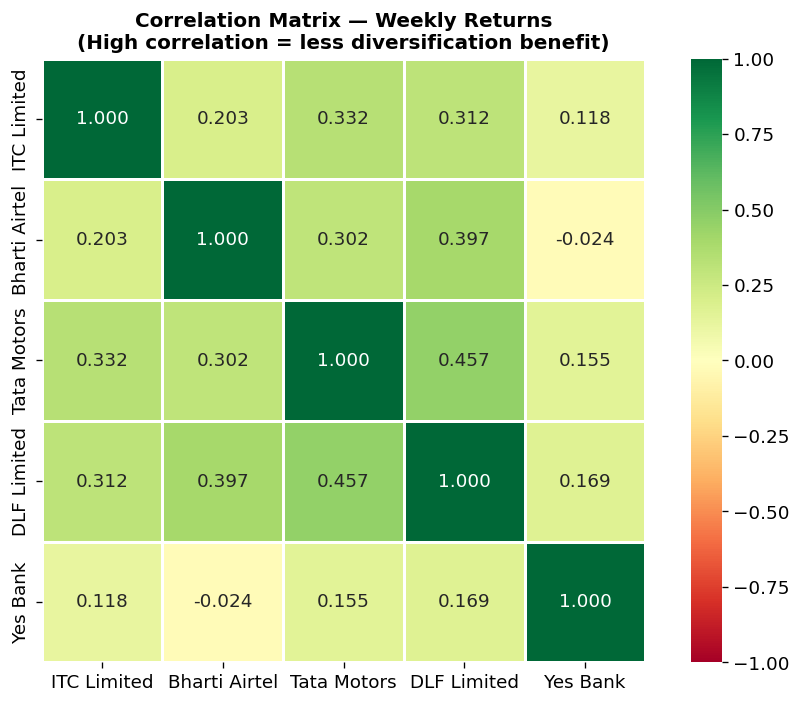

Observation: Most pairs show moderate positive correlation (0.2–0.5), suggesting
some, but not complete, co-movement. DLF and Tata Motors show the highest correlation,
reflecting shared sensitivity to domestic economic cycles.


In [16]:
# Correlation matrix of returns
ret_corr = returns[stocks].corr()
print('Correlation Matrix of Weekly Returns:')
print(ret_corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ret_corr, ax=ax, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.3f', annot_kws={'size': 11},
            linewidths=0.8, linecolor='white', square=True)
ax.set_title('Correlation Matrix — Weekly Returns\n(High correlation = less diversification benefit)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observation: Most pairs show moderate positive correlation (0.2–0.5), suggesting\nsome, but not complete, co-movement. DLF and Tata Motors show the highest correlation,\nreflecting shared sensitivity to domestic economic cycles.')

---
## 7. Actionable Insights & Recommendations

In [17]:
# Summary table
summary = stats[['Mean Return (%)', 'Std Dev (%)', 'Sharpe-like Ratio (Mean/Std)']].copy()
summary['Assessment'] = [
    'Defensive Anchor — low risk, modest return',
    'Core Holding — best risk-adjusted profile',
    'Cyclical Play — high risk, similar return to Airtel',
    'Growth Bet — highest return, elevated risk',
    'AVOID — negative return, highest risk'
]
print('Portfolio Assessment Summary:')
summary

Portfolio Assessment Summary:


,Mean Return (%),Std Dev (%),Sharpe-like Ratio (Mean/Std),Assessment
ITC Limited,0.2281,3.6127,0.0631,"Defensive Anchor — low risk, modest return"
Bharti Airtel,0.4029,3.9073,0.1031,Core Holding — best risk-adjusted profile
Tata Motors,0.4088,6.1976,0.0660,"Cyclical Play — high risk, similar return to A..."
DLF Limited,0.6540,5.7796,0.1132,"Growth Bet — highest return, elevated risk"
Yes Bank,-0.0475,9.1095,-0.0052,"AVOID — negative return, highest risk"


In [ ]:
print("""\n╔══════════════════════════════════════════════════════════════╗
║           ACTIONABLE INSIGHTS & RECOMMENDATIONS              ║
╚══════════════════════════════════════════════════════════════╝

1. BHARTI AIRTEL — CORE PORTFOLIO HOLDING
   Best risk-adjusted return (Sharpe-like ratio = 0.1031).
   Post-Jio disruption recovery is sustained and accelerating.
   5G rollout and ARPU growth support continued positive momentum.
   Recommended allocation: 30-35% of equity portfolio.

2. ITC LIMITED — DEFENSIVE ANCHOR
   Lowest volatility (Std Dev = 3.61%) with positive mean return (0.23%).
   Demonstrated resilience during COVID crash — suitable as a hedge.
   Diversified conglomerate (FMCG, hotels, agribusiness) provides
   natural internal diversification.
   Recommended allocation: 25-30% for capital preservation.

3. DLF LIMITED — TACTICAL GROWTH POSITION
   Highest mean weekly return (0.65%) driven by real estate recovery.
   Cyclical sector — performance is linked to interest rates & housing demand.
   Late-cycle momentum may continue short-term but risk of reversal exists.
   Recommended allocation: 15-20%, with stop-loss discipline.

4. TATA MOTORS — SELECTIVE EXPOSURE
   Similar mean return to Airtel (0.41%) but higher risk (6.20% vs 3.91%).
   JLR exposure adds FX and global demand risk.
   EV transition provides growth optionality but increases uncertainty.
   Recommended allocation: 10-15%, smaller position relative to risk.

5. YES BANK — AVOID OR MINIMAL SPECULATIVE POSITION ONLY
   NEGATIVE mean return (-0.05%) combined with HIGHEST risk (9.11%).
   Shareholder value has been permanently impaired by the 2020 crisis.
   Any allocation should be minimal (<5%) and purely speculative.
   Not suitable for a risk-managed institutional portfolio.

GENERAL PORTFOLIO PRINCIPLES:
- Sector diversification: 5 sectors across 5 stocks reduces concentration risk.
- Position sizing: allocate inversely to volatility (risk-parity approach).
- Review annually: volatility regimes shift — rolling analysis should guide
  rebalancing decisions rather than static historical averages.
- Returns correlation: moderate inter-stock correlation (0.2–0.5) indicates
  meaningful but not complete diversification benefit from holding all 5.
""")